In [11]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

import tensorflow
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import optuna

from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.layers import Dropout


In [12]:
plt.style.use("ggplot")

RANDOM_STATE = 42

In [13]:
df = pd.read_parquet("../data/processed/features_dataset.parquet")

Preprocesamiento básico de los datos (el mismo realizado en el archivo train.py, para estandarizar los datos)

In [14]:
df["date"] = pd.to_datetime(df["date"])

df = (
    df
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

Definimos los features y el target

In [15]:
FEATURES = [
    "lag_1",
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7",
    "sell_price",
    "month",
    "weekday",
    "is_weekend"
]

TARGET = "sales"

Definimos el split temporal que hemos decidido:

In [16]:
days_for_validation = 28

max_date = df["date"].max()

split_date = max_date - pd.Timedelta(days=days_for_validation)

train_df = df[df["date"] < split_date]
valid_df = df[df["date"] >= split_date]

Definimos las matrices: 

In [17]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_valid = valid_df[FEATURES]
y_valid = valid_df[TARGET]

Baseline de MAE:

In [18]:
baseline_pred = valid_df["lag_7"]

baseline_mae = mean_absolute_error(
    y_valid,
    baseline_pred
)

print(f"Baseline MAE: {baseline_mae:.4f}")

Baseline MAE: 1.4267


**Primer Modelo** Random forest básico:

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

rf_mae = mean_absolute_error(
    y_valid,
    rf_pred
)

print(f"Random Forest MAE: {rf_mae:.4f}")

Random Forest MAE: 1.1371


Hay una mejora significativa, ya que pasa de 1.426 a 1.137, lo cual es una mejora de un 20%, lo cual puede generar una gran repercusión en el balance de beneficios total. Ahora probaremos con un modelo que es más capaz y se adaptará mejor a este dataset, el XGBoost:

In [20]:
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=9,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=-1, num_parallel_tree=None, ...)

In [21]:
xgb_pred = xgb_model.predict(X_valid)

xgb_pred = np.clip(xgb_pred, 0, None)

xgb_mae = mean_absolute_error(
    y_valid,
    xgb_pred
)

print(f"XGBoost MAE: {xgb_mae:.4f}")

XGBoost MAE: 1.1634


In [22]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae
    ]
})

results.sort_values("MAE")

,Model,MAE
1,Random Forest,1.137080
2,XGBoost,1.163394
0,Naive Baseline,1.426735


Este modelo, aunque más complejo que el Random Forest anterior, no ha sido capaz de mejorar su error medio, por lo que se considera que es un modelo peor.

**Red Neuronal Simple**

A continuación entrenaremos una red neuronal simple de capas Densas para comprobar si es más capaz durante su etapa de entrenamiento de mejorar los resultados de los modelos anteriores.

In [23]:
np.random.seed(42)
tf.random.set_seed(42)

model2 = Sequential()
model2.add(Dense(120, activation='relu', input_shape=(X_train.shape[1],), kernel_initializer='he_normal'))
model2.add(Dense(65, activation='relu'))
model2.add(Dense(25, activation='relu'))
model2.add(Dense(1))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

model2.compile(optimizer='adam', loss='mae', metrics=['mae'])

history = model2.fit(X_train, y_train, epochs=200, batch_size=32,
          validation_split=0.2,
          verbose=1,callbacks=[early_stop])

# Visualizar la pérdida (MAE) durante el entrenamiento
plt.figure(figsize=(12, 5))
# Pérdida (MAE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida (Entrenamiento)')
plt.plot(history.history['val_loss'], label='Pérdida (Validación)')
plt.title('Función de pérdida (MAE) del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MAE)')
plt.legend()


# EVALUACIÓN
loss, mae = model2.evaluate(X_valid, y_valid, verbose=0)
print('Test MAE: %.3f' % mae)

Epoch 1/200
653/653 [==============================] - 2s 2ms/step - loss: 1.3469 - mae: 1.3469 - val_loss: 1.0532 - val_mae: 1.0532
Epoch 2/200
653/653 [==============================] - 1s 1ms/step - loss: 1.2740 - mae: 1.2740 - val_loss: 1.0448 - val_mae: 1.0448
Epoch 3/200
653/653 [==============================] - 1s 2ms/step - loss: 1.2485 - mae: 1.2485 - val_loss: 1.0337 - val_mae: 1.0337
Epoch 4/200
653/653 [==============================] - 1s 1ms/step - loss: 1.2438 - mae: 1.2438 - val_loss: 1.0195 - val_mae: 1.0195
Epoch 5/200
653/653 [==============================] - 1s 1ms/step - loss: 1.2376 - mae: 1.2376 - val_loss: 1.0365 - val_mae: 1.0365
Epoch 6/200
653/653 [==============================] - 1s 1ms/step - loss: 1.2261 - mae: 1.2261 - val_loss: 1.0081 - val_mae: 1.0081
Epoch 7/200
653/653 [==============================] - 1s 1ms/step - loss: 1.2209 - mae: 1.2209 - val_loss: 0.9966 - val_mae: 0.9966
Epoch 8/200
653/653 [==============================] - 1s 1ms/step - 

KeyboardInterrupt: 

El modelo se ha detenido cerca de las 30 épocas debído al early stopping, pero se puede ver como ha conseguido un MAE inferior a 1, lo que indíca una mejora muy representativa respecto del modelo anterior, por lo que podemos decir que es un modelo que se adapta mejor al dataset. 

Por último, entrenaremos un modelo con capas densas más complejas, para comprobar si el aumento de estas afecta directamente al valor del MAE:

Epoch 1/200
653/653 [==============================] - 3s 2ms/step - loss: 1.3249 - mae: 1.3249 - val_loss: 1.0309 - val_mae: 1.0309
Epoch 2/200
653/653 [==============================] - 1s 2ms/step - loss: 1.2521 - mae: 1.2521 - val_loss: 1.0046 - val_mae: 1.0046
Epoch 3/200
653/653 [==============================] - 1s 2ms/step - loss: 1.2264 - mae: 1.2264 - val_loss: 1.0107 - val_mae: 1.0107
Epoch 4/200
653/653 [==============================] - 1s 2ms/step - loss: 1.2272 - mae: 1.2272 - val_loss: 1.0358 - val_mae: 1.0358
Epoch 5/200
653/653 [==============================] - 1s 2ms/step - loss: 1.2150 - mae: 1.2150 - val_loss: 1.0089 - val_mae: 1.0089
Epoch 6/200
653/653 [==============================] - 1s 2ms/step - loss: 1.2029 - mae: 1.2029 - val_loss: 0.9975 - val_mae: 0.9975
Epoch 7/200
653/653 [==============================] - 1s 2ms/step - loss: 1.2038 - mae: 1.2038 - val_loss: 0.9853 - val_mae: 0.9853
Epoch 8/200
653/653 [==============================] - 1s 2ms/step - 

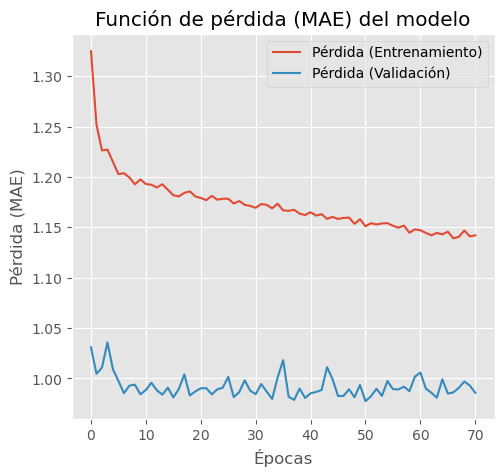

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential()
model.add(Dense(240, activation='relu', input_shape=(X_train.shape[1],), kernel_initializer='he_normal'))
model.add(Dense(150, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(1))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=200, batch_size=32,
          validation_split=0.2,
          verbose=1,callbacks=[early_stop])

# Visualizar la pérdida (MAE) durante el entrenamiento
plt.figure(figsize=(12, 5))
# Pérdida (MAE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida (Entrenamiento)')
plt.plot(history.history['val_loss'], label='Pérdida (Validación)')
plt.title('Función de pérdida (MAE) del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MAE)')
plt.legend()


# EVALUACIÓN
loss, mae = model.evaluate(X_valid, y_valid, verbose=0)
print('Test MAE: %.3f' % mae)

Este modelo ha acabado con un MAE de  1.011, peor que su versión más simple, además, como se puede ver en la gráfica ha tardado casi el doble de épocas en entrenarse. Por lo que se puede determinar que, en general, es un modelo con peor rendimiento y resultados.

Ahora, generaremos un dataset de las predicciones de ventas para poder continuar con el proyecto, haciendo una estimación de stock

In [24]:
y_pred = model2.predict(X_valid).flatten()

y_pred = np.clip(y_pred, 0, None)

348/348 [==============================] - 0s 839us/step


In [25]:
forecast_results = valid_df.copy()
forecast_results["predicted_sales"] = y_pred

#Seleccionamos solo las columnas que son estrictamente operacionales
columns_to_keep = [
    "date", "store_id", "item_id", "sales", 
    "predicted_sales", "rolling_std_7", "sell_price"
]
forecast_results = forecast_results[columns_to_keep]

Añadimos un stock de seguridad (20% sibre la predicción)

In [26]:
SAFETY_STOCK_FACTOR = 1.2

forecast_results["recommended_stock"] = (
    forecast_results["predicted_sales"] * SAFETY_STOCK_FACTOR
).round().astype(np.int32)

print(forecast_results[['date', 'sales', 'predicted_sales', 'recommended_stock']].head())

            date  sales  predicted_sales  recommended_stock
26093 2014-06-15      0         0.000000                  0
26094 2014-06-15      1         0.000000                  0
26095 2014-06-15      1         0.000000                  0
26096 2014-06-15      1         0.000000                  0
26097 2014-06-15      0         0.504662                  1


Guardamos el dataset:

In [27]:
forecast_results.to_parquet("../data/processed/forecast_results.parquet", index=False)